# Finish Multiplier Analysis — Foil vs Etched (same card)

**Research questions — all per-card, same card only:**
1. How does the **foil multiplier** (foil ÷ nonfoil) compare to the **etched multiplier** (etched ÷ nonfoil) for the same card?
2. For cards with **all three finishes**, what is the typical price ranking?
3. Are the foil and etched multipliers correlated?

All comparisons are card-level: same `card_version_id`, same `price_date`.

In [3]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
PARQUET = DATA_DIR / "finish_multipliers.parquet"
REFRESH = True # set True to re-query

MULT_CLIP = (0.2, 20)  # clip outlier multipliers

RARITY_ORDER  = ["mythic", "rare"]
RARITY_COLORS = {"mythic": "#e07b39", "rare": "#c5a800", "uncommon": "#8fb5c2", "common": "#9e9e9e"}

DB_CONFIG = dict(
    host="localhost",
    port=5433,
    dbname="automana",
    user="automana_admin",
    password=os.environ.get("AUTOMANA_DB_PASSWORD", ""),
)

def get_conn():
    return psycopg2.connect(**DB_CONFIG)

def query_to_df(sql):
    with get_conn() as conn:
        cur = conn.cursor()
        cur.execute(sql)
        cols = [d[0] for d in cur.description]
        rows = cur.fetchall()
    return pd.DataFrame(rows, columns=cols)

## Part 0 — Load: one row per card × date, three finish prices as columns

We pivot so that each row is a `(card_version_id, price_date)` with columns `nf_cents`, `foil_cents`, `etched_cents`.
This ensures every multiplier comparison uses the **same card on the same day**.

In [5]:
import pyarrow as pa
import pyarrow.parquet as pq

# max_locks_per_transaction=64; hypertable has weekly chunks (~52/year).
# Querying all years at once exceeds the lock budget — loop one year at a time instead.
SQL_YEAR = """
SELECT
    cv.card_version_id::text                                                       AS card_version_id,
    r.rarity_name,
    s.set_code,
    s.set_name,
    ppd.price_date,
    AVG(ppd.list_avg_cents) FILTER (WHERE cf.code = 'NONFOIL')                   AS nonfoil,
    AVG(ppd.list_avg_cents) FILTER (WHERE cf.code = 'FOIL')                      AS foil,
    AVG(ppd.list_avg_cents) FILTER (WHERE cf.code = 'ETCHED')                    AS etched
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv      ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.card_finished cf     ON cf.finish_id = ppd.finish_id
JOIN card_catalog.rarities_ref r       ON r.rarity_id = cv.rarity_id
JOIN card_catalog.sets s               ON s.set_id = cv.set_id
JOIN card_catalog.set_type_list_ref st ON st.set_type_id = s.set_type_id
WHERE st.set_type = 'expansion'
  AND cf.code IN ('NONFOIL', 'FOIL', 'ETCHED')
  AND r.rarity_name IN ('rare', 'mythic')
  AND ppd.list_avg_cents IS NOT NULL
  AND ppd.list_avg_cents > 0
  AND ppd.price_date >= %(start)s
  AND ppd.price_date <  %(end)s
GROUP BY cv.card_version_id, r.rarity_name, s.set_code, s.set_name, ppd.price_date
"""

if REFRESH or not PARQUET.exists():
    print("Querying DB year by year…")
    writer = None
    total = 0
    for year in range(2021, 2027):
        params = {"start": f"{year}-01-01", "end": f"{year + 1}-01-01"}
        with get_conn() as conn:
            cur = conn.cursor()
            cur.execute(SQL_YEAR, params)
            cols = [d[0] for d in cur.description]
            rows = cur.fetchall()
        if not rows:
            continue
        chunk = pd.DataFrame(rows, columns=cols)
        del rows
        chunk["price_date"] = pd.to_datetime(chunk["price_date"])
        for col in ("nonfoil", "foil", "etched"):
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce")
        table = pa.Table.from_pandas(chunk, preserve_index=False)
        del chunk
        if writer is None:
            writer = pq.ParquetWriter(str(PARQUET), table.schema)
        writer.write_table(table)
        total += len(table)
        print(f"  {year}: {len(table):,} rows")
    if writer:
        writer.close()
    print(f"  Saved {total:,} card × date rows → {PARQUET}")
    wide = pd.read_parquet(PARQUET)
else:
    wide = pd.read_parquet(PARQUET)
    print(f"Loaded {len(wide):,} card × date rows")

# Compute multipliers — only where nonfoil baseline exists
valid = wide[wide["nonfoil"] > 0].copy()
valid["foil_mult"]   = valid["foil"]   / valid["nonfoil"]
valid["etched_mult"] = valid["etched"] / valid["nonfoil"]

has_foil   = valid[valid["foil_mult"].notna()   & (valid["foil_mult"]   > 0)]
has_etched = valid[valid["etched_mult"].notna() & (valid["etched_mult"] > 0)]
has_both   = valid[
    valid["foil_mult"].notna()   & (valid["foil_mult"]   > 0) &
    valid["etched_mult"].notna() & (valid["etched_mult"] > 0)
]
has_all3   = has_both  # same: nonfoil is the baseline

print(f"\nCard × date rows with nonfoil baseline: {len(valid):,}")
print(f"  + foil data:         {len(has_foil):,}  ({has_foil['card_version_id'].nunique():,} unique cards)")
print(f"  + etched data:       {len(has_etched):,}  ({has_etched['card_version_id'].nunique():,} unique cards)")
print(f"  + foil AND etched:   {len(has_both):,}  ({has_both['card_version_id'].nunique():,} unique cards)")


Querying DB year by year…
  2021: 1,427,566 rows
  2022: 2,535,371 rows
  2023: 2,846,884 rows
  2024: 3,213,989 rows
  2025: 3,555,572 rows
  2026: 1,374,122 rows
  Saved 14,953,504 card × date rows → data/finish_multipliers.parquet

Card × date rows with nonfoil baseline: 14,454,027
  + foil data:         12,555,584  (9,389 unique cards)
  + etched data:       3,392  (75 unique cards)
  + foil AND etched:   2,818  (75 unique cards)


## Part 1 — Foil vs Etched Multiplier Distribution

For each rarity, how is the foil multiplier distributed vs the etched multiplier?
These are computed on the **same card vs the same nonfoil baseline on the same date**.

In [6]:
fo_clean = has_foil[has_foil["foil_mult"].between(*MULT_CLIP)]
et_clean = has_etched[has_etched["etched_mult"].between(*MULT_CLIP)]

avail_fo = [r for r in RARITY_ORDER if r in fo_clean["rarity_name"].values]
avail_et = [r for r in RARITY_ORDER if r in et_clean["rarity_name"].values]

print("Foil multiplier (foil list_avg / nonfoil list_avg):")
display(fo_clean.groupby("rarity_name")["foil_mult"]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2).loc[avail_fo])

if not et_clean.empty:
    print("\nEtched multiplier (etched list_avg / nonfoil list_avg):")
    display(et_clean.groupby("rarity_name")["etched_mult"]
            .describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2).loc[avail_et])

Foil multiplier (foil list_avg / nonfoil list_avg):


,count,mean,std,min,25%,50%,75%,90%,max
rarity_name,,,,,,,,,
mythic,2213873.0,2.49,2.14,0.2,1.25,1.66,2.87,4.86,20.0
rare,9581943.0,3.83,3.92,0.2,1.40,2.07,4.54,9.50,20.0



Etched multiplier (etched list_avg / nonfoil list_avg):


,count,mean,std,min,25%,50%,75%,90%,max
rarity_name,,,,,,,,,
mythic,1903.0,1.44,0.62,0.57,0.92,1.27,1.82,2.31,6.17
rare,1278.0,2.70,2.38,0.36,0.62,2.06,4.57,5.18,12.49


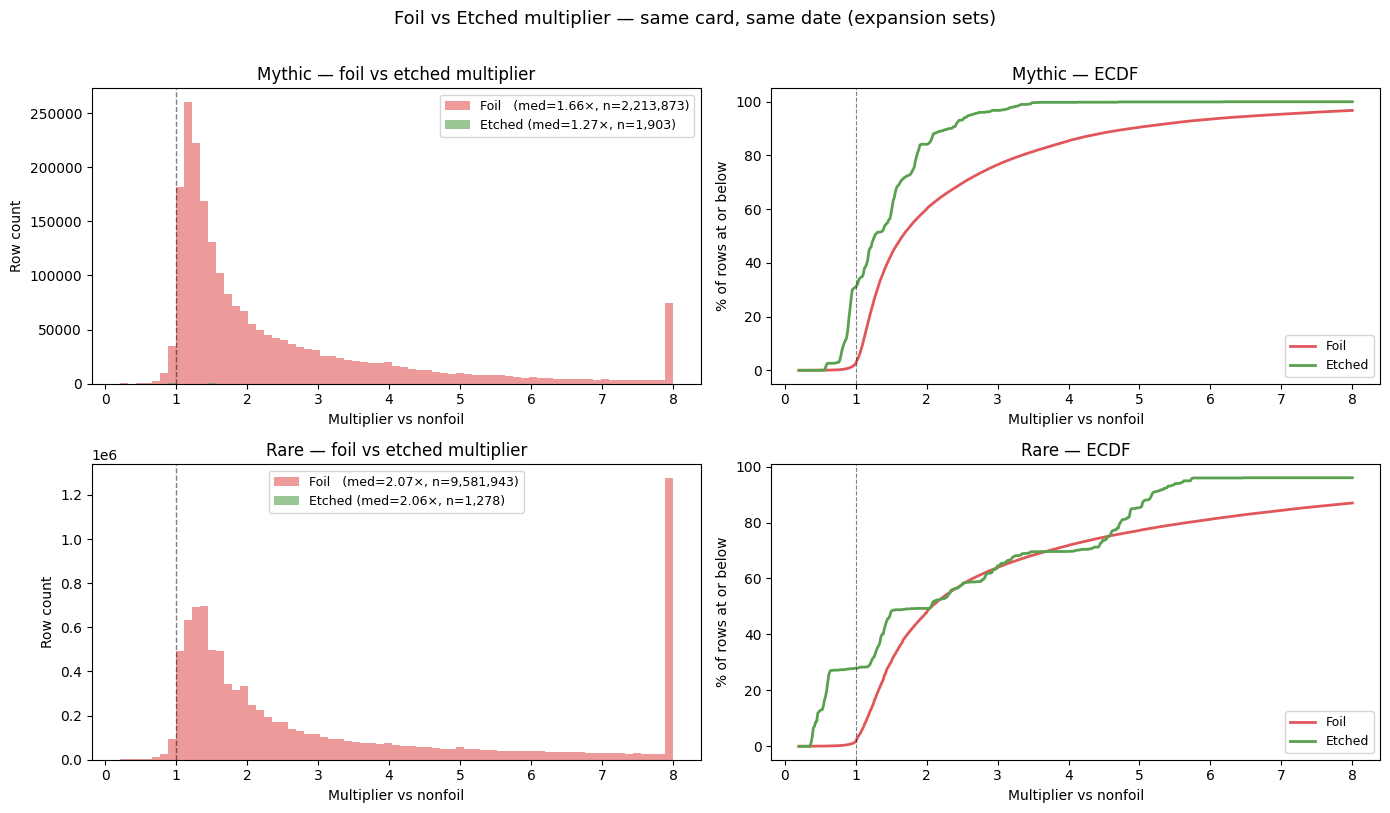

In [7]:
# One row per rarity: overlapping histogram + ECDF
fig, axes = plt.subplots(len(avail_fo), 2, figsize=(14, 4 * len(avail_fo)), squeeze=False)
bins = np.linspace(0.2, 8, 70)
x_grid = np.linspace(0.2, 8, 500)

for row, rarity in enumerate(avail_fo):
    fo_vals = fo_clean[fo_clean["rarity_name"] == rarity]["foil_mult"]
    et_vals = et_clean[et_clean["rarity_name"] == rarity]["etched_mult"] if not et_clean.empty else pd.Series(dtype=float)

    # Left: overlapping histogram
    ax = axes[row, 0]
    ax.hist(fo_vals.clip(upper=8), bins=bins, alpha=0.6, color="#e15759",
            label=f"Foil   (med={fo_vals.median():.2f}×, n={len(fo_vals):,})")
    if not et_vals.empty:
        ax.hist(et_vals.clip(upper=8), bins=bins, alpha=0.6, color="#59a14f",
                label=f"Etched (med={et_vals.median():.2f}×, n={len(et_vals):,})")
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_xlabel("Multiplier vs nonfoil")
    ax.set_ylabel("Row count")
    ax.set_title(f"{rarity.capitalize()} — foil vs etched multiplier")
    ax.legend(fontsize=9)

    # Right: ECDF
    ax = axes[row, 1]
    for vals, label, col in [(fo_vals, "Foil", "#e15759"), (et_vals, "Etched", "#59a14f")]:
        if vals.empty:
            continue
        ecdf = np.array([(vals <= x).mean() for x in x_grid])
        ax.plot(x_grid, ecdf * 100, color=col, linewidth=2, label=label)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Multiplier vs nonfoil")
    ax.set_ylabel("% of rows at or below")
    ax.set_title(f"{rarity.capitalize()} — ECDF")
    ax.legend(fontsize=9)

fig.suptitle("Foil vs Etched multiplier — same card, same date (expansion sets)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "finish_fig1_multiplier_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## Part 2 — Head-to-Head: Foil Multiplier vs Etched Multiplier

For cards that have **both** foil and etched data on the same day (vs the same nonfoil baseline):
- scatter of `foil_mult` vs `etched_mult` per card × date (daily)
- scatter of per-card median foil mult vs per-card median etched mult (one point per card)

Points above the diagonal → etched costs more than foil for that card.  
Points below the diagonal → foil costs more.

In [8]:
both_clean = has_both[
    has_both["foil_mult"].between(*MULT_CLIP) &
    has_both["etched_mult"].between(*MULT_CLIP)
].copy()

# Per-card median
card_mults = (
    both_clean.groupby(["card_version_id", "rarity_name"])[["foil_mult", "etched_mult"]]
    .median().reset_index()
)
card_mults["etched_gt_foil"] = card_mults["etched_mult"] > card_mults["foil_mult"]
card_mults["mult_diff"]       = card_mults["etched_mult"] - card_mults["foil_mult"]

avail_b = [r for r in RARITY_ORDER if r in card_mults["rarity_name"].values]

print(f"Card × date rows with both foil and etched: {len(both_clean):,}")
print(f"Unique cards with both: {card_mults['card_version_id'].nunique():,}")

print("\nPer-card median multipliers:")
display(card_mults.groupby("rarity_name")[["foil_mult", "etched_mult"]]
        .describe(percentiles=[0.25, 0.5, 0.75]).round(2).loc[avail_b])

print("\n% of cards where etched > foil (per-card median):")
print(card_mults.groupby("rarity_name")["etched_gt_foil"].mean().mul(100).round(1)
      .loc[avail_b].rename("etched > foil (%)"))

Card × date rows with both foil and etched: 2,764
Unique cards with both: 73

Per-card median multipliers:


foil_mult                                            etched_mult  \
                count  mean   std   min   25%   50%   75%    max       count   
rarity_name                                                                    
mythic           33.0  1.39  0.49  0.73  1.04  1.31  1.69   2.99        33.0   
rare             40.0  1.76  1.70  0.39  0.99  1.18  1.55  10.04        40.0   

                                                        
             mean   std   min   25%   50%   75%    max  
rarity_name                                             
mythic       2.06  1.40  0.60  0.97  1.51  2.72   6.17  
rare         2.33  2.81  0.41  0.83  1.05  3.19  12.49


% of cards where etched > foil (per-card median):
rarity_name
mythic    63.6
rare      45.0
Name: etched > foil (%), dtype: float64


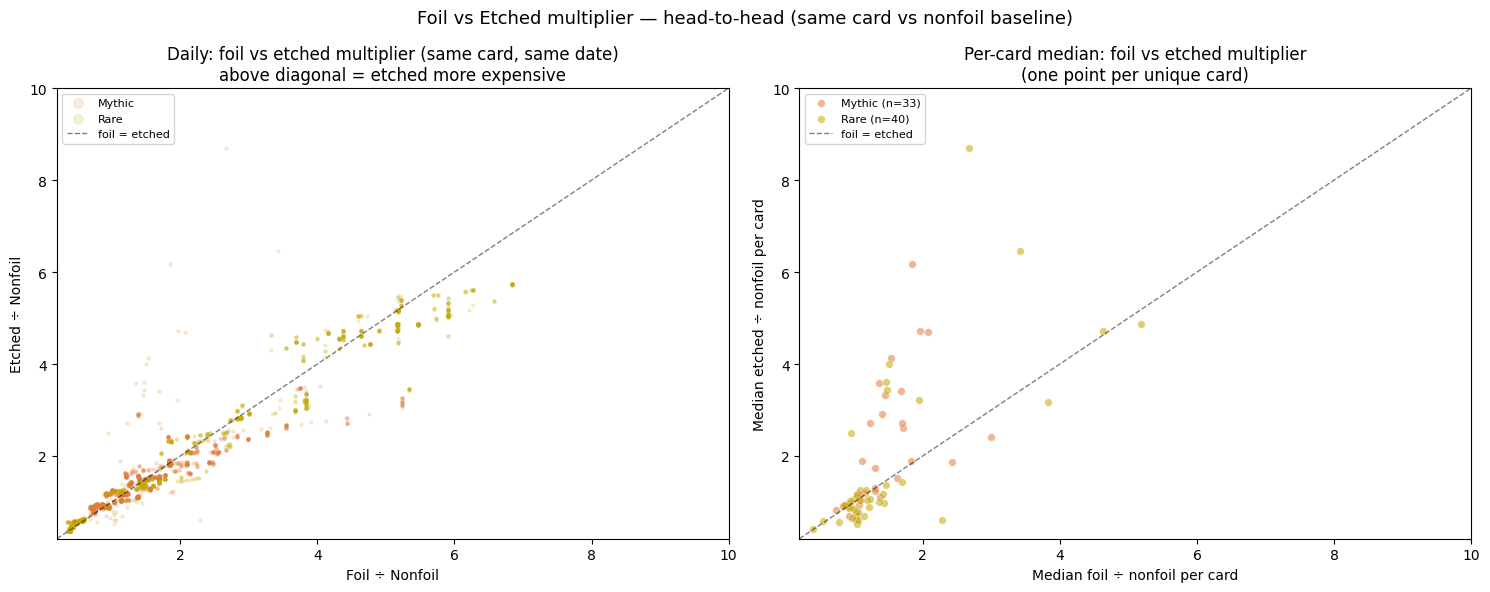

Correlation between foil and etched multiplier (per-card median):
  Pearson r = 0.662   Spearman r = 0.794


In [9]:
lims = [0.2, 10]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: daily scatter (sampled)
ax = axes[0]
samp = both_clean.sample(min(20_000, len(both_clean)), random_state=42)
for rarity in avail_b:
    sub = samp[samp["rarity_name"] == rarity]
    ax.scatter(sub["foil_mult"], sub["etched_mult"],
               color=RARITY_COLORS[rarity], alpha=0.15, s=5, label=rarity.capitalize())
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="foil = etched")
ax.set_xlim(*lims); ax.set_ylim(*lims)
ax.set_xlabel("Foil ÷ Nonfoil")
ax.set_ylabel("Etched ÷ Nonfoil")
ax.set_title("Daily: foil vs etched multiplier (same card, same date)\nabove diagonal = etched more expensive")
ax.legend(fontsize=8, markerscale=3)

# Right: per-card median
ax = axes[1]
for rarity in avail_b:
    sub = card_mults[card_mults["rarity_name"] == rarity]
    ax.scatter(sub["foil_mult"], sub["etched_mult"],
               color=RARITY_COLORS[rarity], alpha=0.55, s=30,
               edgecolors="white", linewidths=0.4,
               label=f"{rarity.capitalize()} (n={len(sub)})")
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="foil = etched")
ax.set_xlim(*lims); ax.set_ylim(*lims)
ax.set_xlabel("Median foil ÷ nonfoil per card")
ax.set_ylabel("Median etched ÷ nonfoil per card")
ax.set_title("Per-card median: foil vs etched multiplier\n(one point per unique card)")
ax.legend(fontsize=8)

fig.suptitle("Foil vs Etched multiplier — head-to-head (same card vs nonfoil baseline)", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "finish_fig2_head_to_head.png", dpi=150)
plt.show()

r, _ = stats.pearsonr(card_mults["foil_mult"], card_mults["etched_mult"])
sp, _ = stats.spearmanr(card_mults["foil_mult"], card_mults["etched_mult"])
print(f"Correlation between foil and etched multiplier (per-card median):")
print(f"  Pearson r = {r:.3f}   Spearman r = {sp:.3f}")

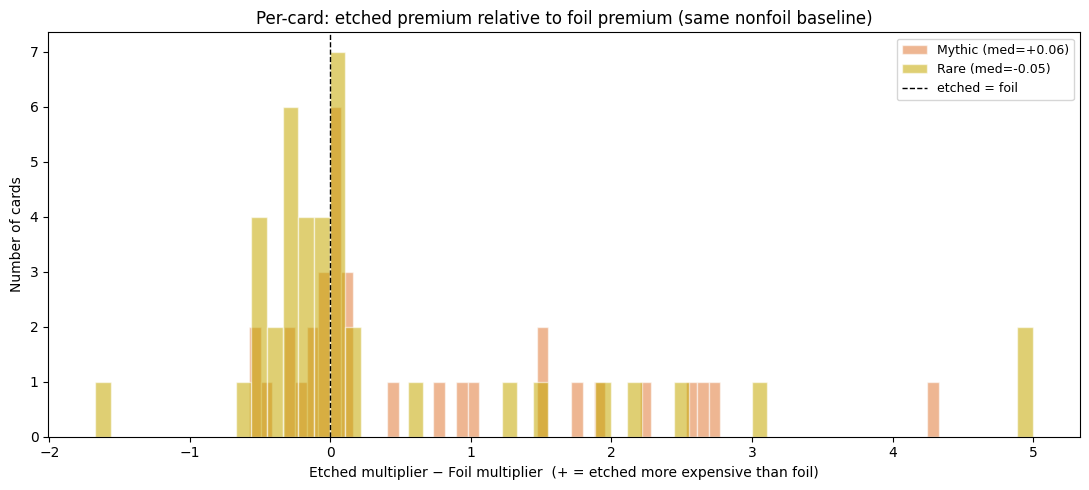

In [10]:
# Distribution of (etched_mult - foil_mult) per card
fig, ax = plt.subplots(figsize=(11, 5))
for rarity in avail_b:
    sub = card_mults[card_mults["rarity_name"] == rarity]["mult_diff"]
    med = sub.median()
    ax.hist(sub.clip(-5, 5), bins=60, color=RARITY_COLORS[rarity], alpha=0.55,
            edgecolor="white", label=f"{rarity.capitalize()} (med={med:+.2f})")
ax.axvline(0, color="black", linestyle="--", linewidth=1, label="etched = foil")
ax.set_xlabel("Etched multiplier − Foil multiplier  (+ = etched more expensive than foil)")
ax.set_ylabel("Number of cards")
ax.set_title("Per-card: etched premium relative to foil premium (same nonfoil baseline)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / "finish_fig3_mult_diff.png", dpi=150)
plt.show()

## Part 3 — Three-Way: Nonfoil vs Foil vs Etched (same card)

For cards that have **all three finishes** on the same day:
- What is the typical price ranking (cheapest → most expensive)?
- How often is each ordering observed?
- Boxplot of absolute prices and multipliers.

In [11]:
three = wide[
    (wide["nonfoil"] > 0) &
    (wide["foil"].notna())   & (wide["foil"] > 0) &
    (wide["etched"].notna()) & (wide["etched"] > 0)
].copy()
three["foil_mult"]   = three["foil"]   / three["nonfoil"]
three["etched_mult"] = three["etched"] / three["nonfoil"]
three = three[
    three["foil_mult"].between(*MULT_CLIP) &
    three["etched_mult"].between(*MULT_CLIP)
].copy()

print(f"Card × date rows with all three finishes: {len(three):,}")
print(f"Unique cards: {three['card_version_id'].nunique():,}")

def rank_finishes(row):
    return " < ".join(k for k, _ in sorted(
        [("nonfoil", row["nonfoil"]), ("foil", row["foil"]), ("etched", row["etched"])],
        key=lambda x: x[1]
    ))

three["ordering"] = three.apply(rank_finishes, axis=1)
order_counts = three["ordering"].value_counts()
total = len(three)

print("\nPrice orderings (cheapest → most expensive):")
for order, count in order_counts.head(10).items():
    print(f"  {order:<35s}  {count:>7,}  ({count/total*100:.1f}%)")

Card × date rows with all three finishes: 2,764
Unique cards: 73

Price orderings (cheapest → most expensive):
  nonfoil < etched < foil                1,103  (39.9%)
  foil < etched < nonfoil                  742  (26.8%)
  nonfoil < foil < etched                  709  (25.7%)
  etched < foil < nonfoil                  126  (4.6%)
  foil < nonfoil < etched                   67  (2.4%)
  etched < nonfoil < foil                   17  (0.6%)


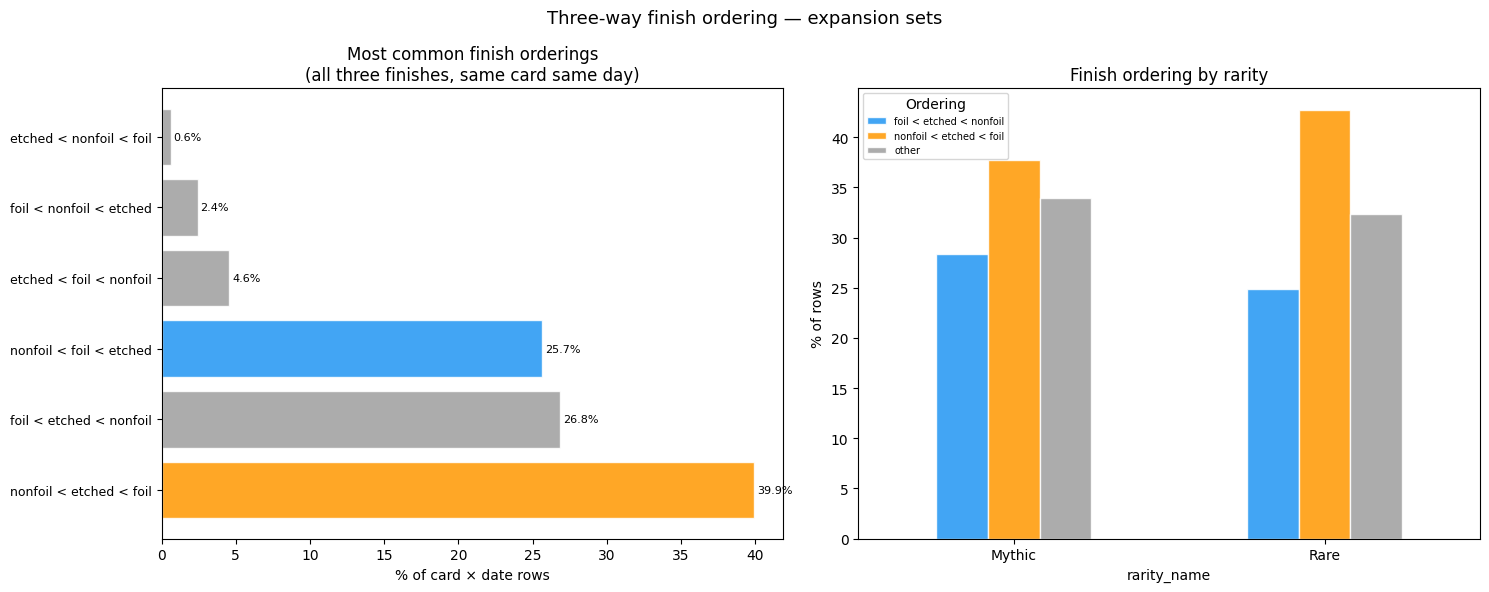

In [12]:
avail_r3 = [r for r in RARITY_ORDER if r in three["rarity_name"].values]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: overall ordering bar chart
ax = axes[0]
top_orders = order_counts.head(6)
pcts = top_orders / total * 100
ORDER_PALETTE = {"nonfoil < foil < etched": "#2196f3",
                 "nonfoil < etched < foil": "#ff9800"}
colors = [ORDER_PALETTE.get(o, "#9e9e9e") for o in pcts.index]
bars = ax.barh(range(len(pcts)), pcts.values, color=colors, alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(pcts)))
ax.set_yticklabels(pcts.index, fontsize=9)
ax.set_xlabel("% of card × date rows")
ax.set_title("Most common finish orderings\n(all three finishes, same card same day)")
for bar, v in zip(bars, pcts.values):
    ax.text(v + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}%", va="center", fontsize=8)

# Right: ordering by rarity
ax = axes[1]
top2 = order_counts.head(2).index.tolist()
def classify(o):
    if o == top2[0]: return top2[0]
    if len(top2) > 1 and o == top2[1]: return top2[1]
    return "other"
three["order_class"] = three["ordering"].apply(classify)
rarity_pcts = (
    three.groupby(["rarity_name", "order_class"]).size().unstack(fill_value=0)
    .div(three.groupby("rarity_name").size(), axis=0).mul(100)
    .loc[avail_r3]
)
rarity_pcts.plot(kind="bar", ax=ax, edgecolor="white", alpha=0.85,
                 color=["#2196f3", "#ff9800", "#9e9e9e"][:len(rarity_pcts.columns)])
ax.set_xticklabels([r.capitalize() for r in avail_r3], rotation=0)
ax.set_ylabel("% of rows")
ax.set_title("Finish ordering by rarity")
ax.legend(fontsize=7, title="Ordering")

fig.suptitle("Three-way finish ordering — expansion sets", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "finish_fig4_three_way_ordering.png", dpi=150)
plt.show()

/tmp/ipykernel_6435/2348426110.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Nonfoil", "Foil", "Etched"],
/tmp/ipykernel_6435/2348426110.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_mult, labels=["Foil÷NF", "Etched÷NF"],
/tmp/ipykernel_6435/2348426110.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Nonfoil", "Foil", "Etched"],
/tmp/ipykernel_6435/2348426110.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dro

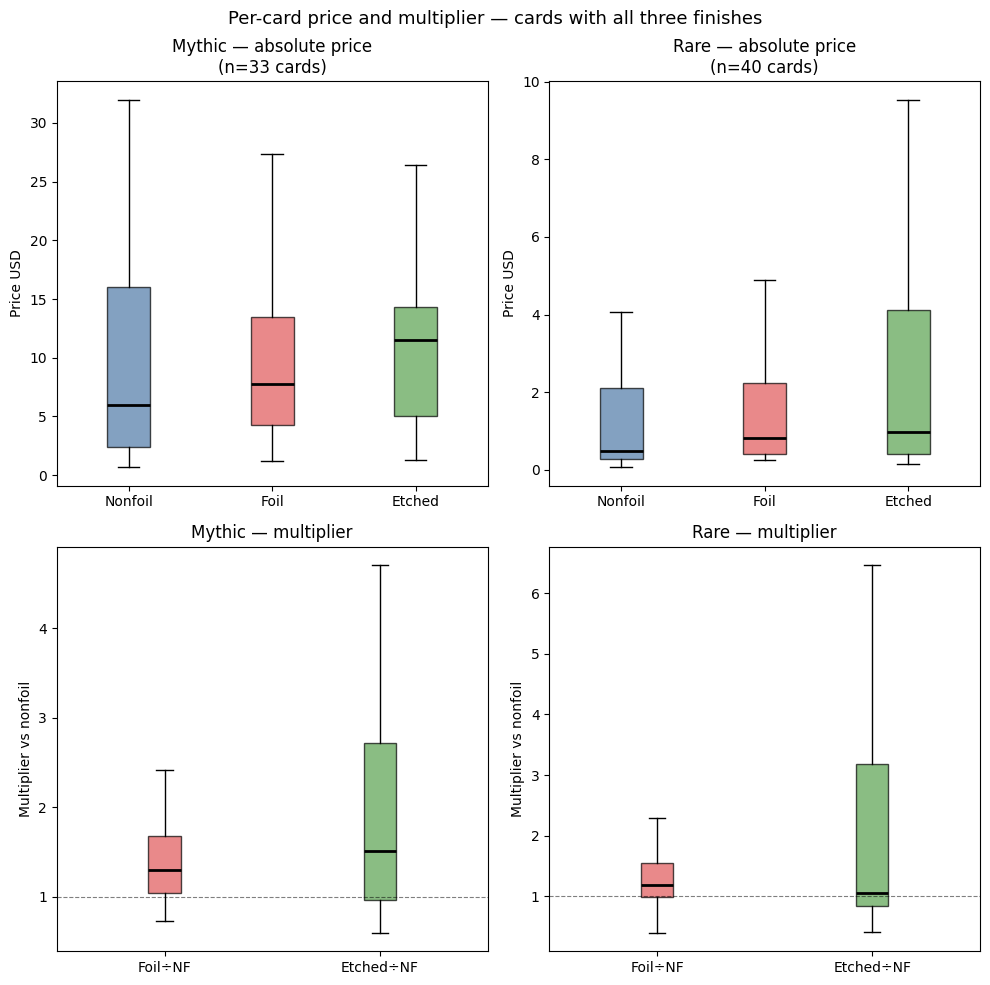

In [13]:
# Per-card median across all dates
card3 = (
    three.groupby(["card_version_id", "rarity_name"])
    [["nonfoil", "foil", "etched", "foil_mult", "etched_mult"]]
    .median().reset_index()
)

fig, axes = plt.subplots(2, len(avail_r3), figsize=(5 * len(avail_r3), 10), squeeze=False)

for col_idx, rarity in enumerate(avail_r3):
    sub = card3[card3["rarity_name"] == rarity]

    # Top row: absolute prices
    ax = axes[0, col_idx]
    data = [(sub[f] / 100).clip(upper=500).values for f in ["nonfoil", "foil", "etched"]]
    bp = ax.boxplot(data, labels=["Nonfoil", "Foil", "Etched"],
                    patch_artist=True, medianprops=dict(color="black", linewidth=2),
                    showfliers=False)
    for patch, c in zip(bp["boxes"], ["#4e79a7", "#e15759", "#59a14f"]):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_ylabel("Price USD")
    ax.set_title(f"{rarity.capitalize()} — absolute price\n(n={len(sub)} cards)")

    # Bottom row: multipliers
    ax = axes[1, col_idx]
    data_mult = [sub["foil_mult"].clip(*MULT_CLIP).values,
                 sub["etched_mult"].clip(*MULT_CLIP).values]
    bp = ax.boxplot(data_mult, labels=["Foil÷NF", "Etched÷NF"],
                    patch_artist=True, medianprops=dict(color="black", linewidth=2),
                    showfliers=False)
    for patch, c in zip(bp["boxes"], ["#e15759", "#59a14f"]):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_ylabel("Multiplier vs nonfoil")
    ax.set_title(f"{rarity.capitalize()} — multiplier")

fig.suptitle("Per-card price and multiplier — cards with all three finishes", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "finish_fig5_three_way_price.png", dpi=150)
plt.show()

## Part 4 — Summary

In [16]:
print("FINISH MULTIPLIER SUMMARY")
print("=" * 55)

for rarity in avail_fo:
    fo_v = fo_clean[fo_clean["rarity_name"] == rarity]["foil_mult"]
    et_v = et_clean[et_clean["rarity_name"] == rarity]["etched_mult"] if not et_clean.empty else pd.Series(dtype=float)
    n_cards = fo_clean[fo_clean["rarity_name"] == rarity]["card_version_id"].nunique()
    print(f"\n{rarity.upper()}")
    print(f"  Foil÷NF   : median={fo_v.median():.2f}×  IQR [{fo_v.quantile(0.25):.2f}–{fo_v.quantile(0.75):.2f}]  "
          f"(n={n_cards} cards)")
    if not et_v.empty:
        print(f"  Etched÷NF : median={et_v.median():.2f}×  IQR [{et_v.quantile(0.25):.2f}–{et_v.quantile(0.75):.2f}]")

if not card_mults.empty:
    r, _ = stats.pearsonr(card_mults["foil_mult"], card_mults["etched_mult"])
    pct_et_gt = card_mults["etched_gt_foil"].mean() * 100
    print(f"\n--- Head-to-head (same card, foil vs etched) ---")
    print(f"  Cards with both finishes:    {card_mults['card_version_id'].nunique():,}")
    print(f"  Etched > foil (% of cards):  {pct_et_gt:.1f}%")
    print(f"  Pearson r (foil vs etched):  {r:.3f}")

if not three.empty:
    top = order_counts.index[0]
    top_pct = order_counts.iloc[0] / total * 100
    print(f"\n--- Three-way (nonfoil + foil + etched) ---")
    print(f"  Cards with all three:        {three['card_version_id'].nunique():,}")
    print(f"  Most common ordering:        {top} ({top_pct:.1f}%)")

FINISH MULTIPLIER SUMMARY

MYTHIC
  Foil÷NF   : median=1.66×  IQR [1.25–2.87]  (n=1838 cards)
  Etched÷NF : median=1.27×  IQR [0.92–1.82]

RARE
  Foil÷NF   : median=2.07×  IQR [1.40–4.54]  (n=7469 cards)
  Etched÷NF : median=2.06×  IQR [0.62–4.57]

--- Head-to-head (same card, foil vs etched) ---
  Cards with both finishes:    73
  Etched > foil (% of cards):  53.4%
  Pearson r (foil vs etched):  0.662

--- Three-way (nonfoil + foil + etched) ---
  Cards with all three:        73
  Most common ordering:        nonfoil < etched < foil (39.9%)
